In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/home/gbemike/Documents/github/GrokResearch/outputs/toxicity_analysis_results/merged_results.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438165 entries, 0 to 438164
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   conversationId  438165 non-null  int64  
 1   threadId        438165 non-null  int64  
 2   grok_reply      438165 non-null  object 
 3   language        438165 non-null  object 
 4   toxicity_score  438165 non-null  float64
 5   category        438165 non-null  object 
 6   role            438165 non-null  object 
dtypes: float64(1), int64(2), object(4)
memory usage: 23.4+ MB


In [4]:
df.head()

,conversationId,threadId,grok_reply,language,toxicity_score,category,role
0,1904185729736937941,1904865884469964876,"Muhammad Yunus, leading Bangladesh's interim g...",id,0.0,non_toxic,assistant
1,1904125001638326602,1904231682863222935,"आर्यभटीय, 5वीं सदी का गणित ग्रंथ, 1465 ई. में ...",mr,0.0,non_toxic,assistant
2,1904125001638326602,1904231682863222935,"वेद मौखिक रूप से संरक्षित थे, इसलिए संस्कृत मे...",mr,0.0,non_toxic,assistant
3,1904125001638326602,1904231682863222935,"अशोक ने प्राकृत में शिलालेख लिखवाए, संस्कृत मे...",mr,0.0,non_toxic,assistant
4,1904125001638326602,1904231682863222935,आर्यभटीय का सबसे पुराना ज्ञात पांडुलिपि 1465 ई...,mr,0.0,non_toxic,assistant


In [5]:
df['category'].value_counts()

category
non_toxic          437799
obscene               150
toxicity              117
insult                 63
sexual_explicit        36
Name: count, dtype: int64

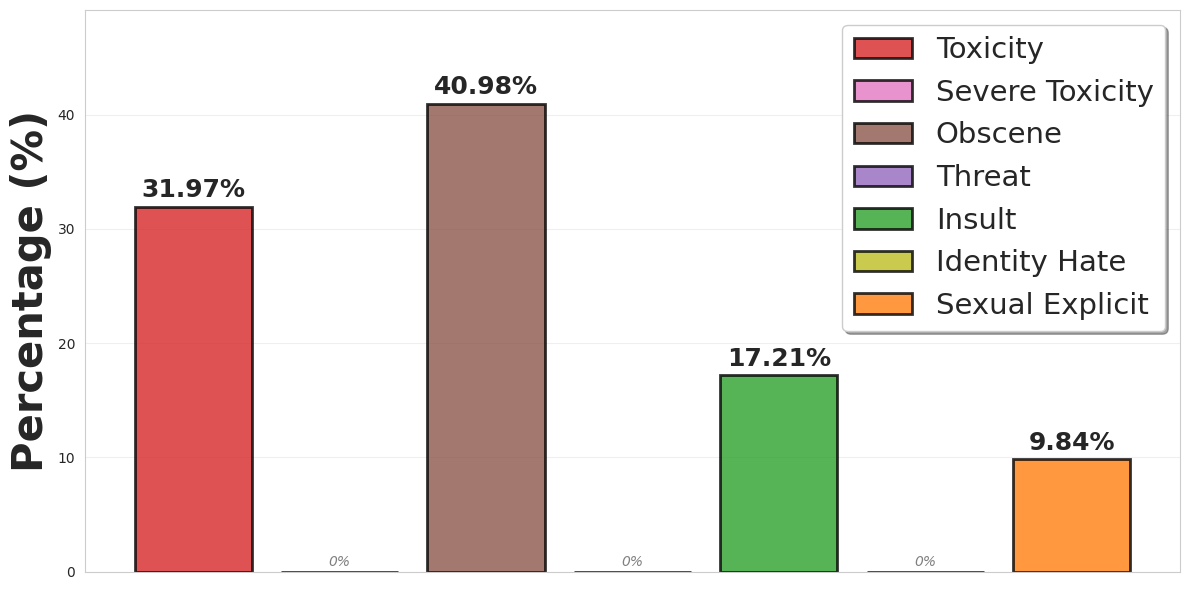

In [9]:
sns.set_style("whitegrid")

toxic_df = df[df['category'] != 'non_toxic']

all_toxic_categories = [
    'toxicity',
    'severe_toxicity',
    'obscene',
    'threat',
    'insult',
    'identity_hate',
    'sexual_explicit'
]

plt.figure(figsize=(12, 6))

seaborn_colors = sns.color_palette("tab10")

color_mapping = {
    'toxicity': seaborn_colors[3],       # red
    'severe_toxicity': seaborn_colors[6], # pink
    'obscene': seaborn_colors[5],        # brown
    'threat': seaborn_colors[4],         # purple
    'insult': seaborn_colors[2],         # green
    'identity_hate': seaborn_colors[8],  # light Blue
    'sexual_explicit': seaborn_colors[1] # orange
}

# label mapping
label_mapping = {
    'toxicity': 'Toxicity',
    'severe_toxicity': 'Severe Toxicity',
    'obscene': 'Obscene',
    'threat': 'Threat',
    'insult': 'Insult',
    'identity_hate': 'Identity Hate',
    'sexual_explicit': 'Sexual Explicit'
}

# get counts for all categories (including 0s)
category_counts = toxic_df['category'].value_counts()
total_toxic = len(toxic_df)

# build data for bar chart
categories = []
percentages = []
counts = []
bar_colors = []

for cat in all_toxic_categories:
    count = category_counts.get(cat, 0)
    percentage = (count / total_toxic * 100) if total_toxic > 0 else 0
    
    categories.append(label_mapping[cat])
    percentages.append(percentage)
    counts.append(count)
    bar_colors.append(color_mapping[cat])

# Create bars with labels for legend
x_positions = range(len(categories))
bars = []
for i, (pos, pct, color, label) in enumerate(zip(x_positions, percentages, bar_colors, categories)):
    bar = plt.bar(pos, pct, color=color, edgecolor='black', linewidth=2, alpha=0.8, label=label)
    bars.append(bar)

# Add percentage labels on bars
for i, (pct, count) in enumerate(zip(percentages, counts)):
    if count > 0:  # Only show label if count > 0
        plt.text(i, pct + max(percentages)*0.02, f'{pct:.2f}%', 
                 ha='center', fontsize=18, weight='bold')
    else:
        plt.text(i, 0.5, '0%', ha='center', fontsize=10, style='italic', color='gray')

# Customize
plt.ylabel('Percentage (%)', fontsize=30, weight='bold')
plt.ylim(0, max(percentages) * 1.2 if max(percentages) > 0 else 10)

# Remove x-axis labels and use legend instead
plt.xticks([])
plt.xlabel('')

# Add legend
plt.legend(loc='upper right', fontsize=21, frameon=True, shadow=True)

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/home/gbemike/Documents/github/GrokResearch/outputs/images/toxicity_bar_chart.png', dpi=300, bbox_inches='tight')
plt.show()



In [13]:
# Print summary
print("TOXIC CONTENT ANALYSIS \n")
print(f"Total Replies: {len(df):,}")
print(f"Non-Toxic Replies: {len(df) - total_toxic:,} ({(len(df) - total_toxic)/len(df)*100:.2f}%)")
print(f"Toxic Replies: {total_toxic:,} ({total_toxic/len(df)*100:.2f}%)")
print("\nTOXIC CATEGORY BREAKDOWN")
for cat, label in label_mapping.items():
    count = category_counts.get(cat, 0)
    percentage = (count / total_toxic * 100) if total_toxic > 0 else 0
    print(f"{label}: {count:,} ({percentage:.2f}% of toxic)")

TOXIC CONTENT ANALYSIS 

Total Replies: 438,165
Non-Toxic Replies: 437,799 (99.92%)
Toxic Replies: 366 (0.08%)

TOXIC CATEGORY BREAKDOWN
Toxicity: 117 (31.97% of toxic)
Severe Toxicity: 0 (0.00% of toxic)
Obscene: 150 (40.98% of toxic)
Threat: 0 (0.00% of toxic)
Insult: 63 (17.21% of toxic)
Identity Hate: 0 (0.00% of toxic)
Sexual Explicit: 36 (9.84% of toxic)
